# 06 — Performance

**Workstream E, tasks E2–E10.** Turns the raw results frame from notebook 05 into the tables and figures
of report section 5 (*Results*). Every headline figure is **net of costs** and is a **median across the
100 experiments**.

| Task | Output |
| --- | --- |
| E2 | **Table 4.1 — Performance conventions** |
| E3, E6 | **Table 4.2 — Net performance by strategy** (gross twin: Table A4.1) |
| E4 | **Table 4.3 — Dispersion** |
| E5 | **Figure 4.1 — Sharpe ratio across 100 experiments** |
| E6 | **Figure 4.2 — Win rate vs equally weighted** |
| E7 | **Table 4.4 — Cost impact** |
| E8 | **Figure 4.3 — Growth of $1** (all eight: Figure A4.1) |
| E9 | **Figure 4.4 — Portfolio weights over time** |
| E10 | **Table A.1 — Optimisation failures** |

**The 100 experiments are not 100 independent tests.** The windows overlap in time (Table 3.1 and
Table A3.2) and share assets, so a win rate of 55% across them is a description of these samples, not
a significance test. The report never treats them as independent.

## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import backtest as bt
from src import config as cfg
from src import data, fmt, viz
from src import performance as pf
from src import strategies as st

viz.use_house_style()
np.random.seed(cfg.SEED)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 140)


#: The strategy the report recommends, for a capital-preservation / moderate-risk investor (report §1, §7).
#: Changing this redraws Figures 4.3-4.4 and nothing else.
RECOMMENDED = "ERC"

---

## The grid

Rebuilt exactly as in notebook 05, which asserts that the rebuild is bit-identical.

In [2]:
close, volume, extraction_date = data.download_raw()
panel = data.build_panel(close, volume, extraction_date)
prices = panel.prices[cfg.ASSET_ORDER]
experiments = bt.sample_experiments(prices)

grid = pf.run_grid(prices, experiments, st.STRATEGIES, panel.risk_free)
results = pf.results_frame(grid, panel.risk_free)

print(f"Extraction date : {panel.extraction_date.isoformat()}")
print(f"Seed            : {cfg.SEED}")
print(f"Runs            : {len(grid.runs):,} at 1x costs + {len(grid.stressed):,} at 2x")

Extraction date : 2026-10-07
Seed            : 20261001
Runs            : 800 at 1x costs + 800 at 2x


---

## E2 — Table 4.1, performance conventions

The brief asks for the precise conventions, including annualisation, the risk-free rate and the
drawdown denominator. Each formula below is exactly what `src/performance.py` computes. All metrics are
measured on the **evaluation year only** (252 sessions).

**Sterling.** We use the classic form, annualised return over |average annual maximum drawdown| plus
10%. With a one-year evaluation the average is that year's maximum drawdown, so Sterling is Calmar with
a 10-point cushion in the denominator. The cushion matters here: GMV and the risk-based strategies often
have drawdowns of only a few percent, and without it Calmar for those runs can run to double digits.

In [3]:
print("Table 4.1 - Performance conventions. Daily simple returns over each experiment's evaluation year "
      f"(n = {cfg.TRADING_DAYS} sessions); r_f from ^IRX.")
display(pf.conventions_table())

Table 4.1 - Performance conventions. Daily simple returns over each experiment's evaluation year (n = 252 sessions); r_f from ^IRX.


,Formula,Annualisation,Risk-free,Drawdown / denominator
Metric,,,,
Ann. return,(∏(1 + rₜ))^(252/n) − 1,"Geometric; n = 252 sessions, so it is the evaluation year's total return",Not subtracted,—
Ann. volatility,sd(rₜ) × √252,√252 on daily sd (ddof = 1),—,—
Sharpe,"mean(rₜ − r_f,ₜ) × 252 / (sd(rₜ − r_f,ₜ) × √252)","Arithmetic mean ×252, sd ×√252","^IRX daily: yield ÷ 100 ÷ 252, each session",—
Sortino,"mean(rₜ − r_f,ₜ) × 252 / (√mean(min(rₜ − r_f,ₜ, 0)²) × √252)","As Sharpe; downside deviation over all sessions, target r_f",^IRX daily,—
Max drawdown,min over t of Wₜ / maxₛ≤ₜ Wₛ − 1,None — measured over the evaluation year,—,"Wealth path W from 1 at the start of the evaluation year, so a fall from the start counts"
Calmar,Ann. return / |max drawdown|,Annualised return,Not subtracted,|Max drawdown|
Sterling,Ann. return / (|max drawdown| + 10%),Annualised return,Not subtracted,|Average annual max drawdown| + 10% (Jones). With one evaluation year the average is that year's max drawdown. The cushion keeps the rat...
Turnover,"Σ over rebalances of Σᵢ|Δwᵢ|, ÷ evaluation years",Per year; two-way,—,Excludes the opening trade from cash
Gross / net,Net deducts Σᵢ|Δwᵢ| × bpᵢ at each trade,—,—,Definitions §6 bp; 2× in workstream F


---

## E3, E6 — Table 4.2, net performance by strategy

Medians across the 100 experiments, net of costs. *Beats EW* is the share of experiments in which the
strategy's net Sharpe ratio exceeds the equally weighted portfolio's **in the same experiment** (E6).
Each median is taken column by column, so a row is not one experiment's results.

In [4]:
PCT = lambda dp: (lambda v: fmt.percent(v, dp))
headline_rules = {"Ann. return %": PCT(2), "Ann. vol %": PCT(2), "Sharpe": lambda v: fmt.number(v, 2),
                  "Max DD %": PCT(2), "Sterling": lambda v: fmt.number(v, 2), "Turnover %/yr": PCT(1),
                  "Beats EW (Sharpe) %": PCT(0)}

table_4_2 = pf.headline_table(results, "net")
print("Table 4.2 - Net performance by strategy. 100 experiments, median across runs, net of costs "
      f"(definitions §6). Evaluation years {experiments['evaluation_start'].min().date()} to "
      f"{experiments['end'].max().date()}; Yahoo Finance, extracted {panel.extraction_date.isoformat()}.")
display(fmt.style(table_4_2, headline_rules))

Table 4.2 - Net performance by strategy. 100 experiments, median across runs, net of costs (definitions §6). Evaluation years 2014-11-24 to 2026-09-30; Yahoo Finance, extracted 2026-10-07.


metric,Ann. return %,Ann. vol %,Sharpe,Max DD %,Sterling,Turnover %/yr,Beats EW (Sharpe) %
strategy,,,,,,,
EW,22.45,20.40,1.06,-14.75,0.89,31.8,—
GMV,3.73,5.98,0.35,-5.29,0.28,20.6,30
MV,19.62,39.86,0.71,-29.84,0.64,201.6,27
MSR,11.27,25.54,0.71,-17.41,0.47,177.9,40
IV,10.98,9.15,1.07,-7.35,0.65,27.8,43
ERC,10.98,8.89,1.06,-7.35,0.64,28.2,41
MDP,10.32,8.47,1.01,-7.48,0.60,35.6,40
MDC,23.16,20.70,1.09,-15.35,0.92,43.2,55


In [5]:
# Supporting numbers the prose cites, computed rather than typed.
net_sharpe = results[("net", "sharpe")].unstack("strategy")
for s in cfg.STRATEGY_ORDER:
    vol_ratio = table_4_2.loc[s, "Ann. vol %"] / table_4_2.loc["EW", "Ann. vol %"]
    print(f"{s:<4} median vol {vol_ratio:4.2f}x EW's   |   median max DD "
          f"{table_4_2.loc[s, 'Max DD %']:6.2f}% vs EW {table_4_2.loc['EW', 'Max DD %']:6.2f}%")

EW   median vol 1.00x EW's   |   median max DD -14.75% vs EW -14.75%
GMV  median vol 0.29x EW's   |   median max DD  -5.29% vs EW -14.75%
MV   median vol 1.95x EW's   |   median max DD -29.84% vs EW -14.75%
MSR  median vol 1.25x EW's   |   median max DD -17.41% vs EW -14.75%
IV   median vol 0.45x EW's   |   median max DD  -7.35% vs EW -14.75%
ERC  median vol 0.44x EW's   |   median max DD  -7.35% vs EW -14.75%
MDP  median vol 0.42x EW's   |   median max DD  -7.48% vs EW -14.75%
MDC  median vol 1.01x EW's   |   median max DD -15.35% vs EW -14.75%


**Reading Table 4.2.** Three groups emerge.

- **EW and MDC** have the highest median returns and EW-level risk. MDC ignores volatility and these
  assets are weakly correlated, so it ends up close to EW.
- **IV, ERC and MDP** match EW's median Sharpe ratio at **less than half its volatility and half its
  drawdown**, with similar or lower turnover. They earn the same return per unit of risk, but take
  much less risk.
- **GMV, MV and MSR** trail. GMV gives up most of the return to minimise variance. MV and MSR lean on
  noisy trailing means: they turn over around 200% a year, carry the deepest drawdowns, and beat EW in
  well under half the experiments. That is the estimation-error shortcoming flagged in Table 3.2.

No optimised strategy beats EW in a clear majority of experiments. That is consistent with the
literature on naive diversification, and is a finding worth stating rather than hiding.

---

## E4 — Table 4.3, dispersion

In [6]:
table_4_3 = pf.dispersion_table(results, "net")
print("Table 4.3 - Dispersion across the 100 experiments, net of costs. IQR = 75th minus 25th percentile; "
      "P10 / P90 = 10th / 90th percentiles. Net return is the evaluation year's annualised return.")
display(fmt.style(table_4_3, {c: (lambda v: fmt.number(v, 2)) for c in table_4_3.columns}))

Table 4.3 - Dispersion across the 100 experiments, net of costs. IQR = 75th minus 25th percentile; P10 / P90 = 10th / 90th percentiles. Net return is the evaluation year's annualised return.


Sharpe                    Net return %                       
         Median   IQR    P10   P90       Median    IQR     P10     P90
strategy                                                              
EW         1.06  1.67  -0.16  2.65        22.45  39.47   -3.92   87.41
GMV        0.35  1.65  -0.84  2.00         3.73   9.50   -3.65   26.01
MV         0.71  1.51  -0.61  2.24        19.62  80.30  -20.49  120.08
MSR        0.71  1.41  -0.73  2.30        11.27  36.10  -19.62   87.64
IV         1.07  1.62  -0.25  2.58        10.98  20.72   -1.58   39.67
ERC        1.06  1.65  -0.29  2.57        10.98  18.77   -2.31   39.84
MDP        1.01  1.65  -0.33  2.58        10.32  20.16   -1.29   41.24
MDC        1.09  1.65  -0.09  2.67        23.16  39.79   -3.59   78.81

Dispersion dwarfs the differences between medians. The Sharpe IQR is about 1.4–1.7 for every
strategy, while the medians of the leading five sit within about 0.1 of each other. Which year and
which four assets an experiment drew matters far more than which strategy ran on them. Workstream F
(period and subset dependence) picks this up.

---

## E5 — Figure 4.1, Sharpe ratio across the 100 experiments

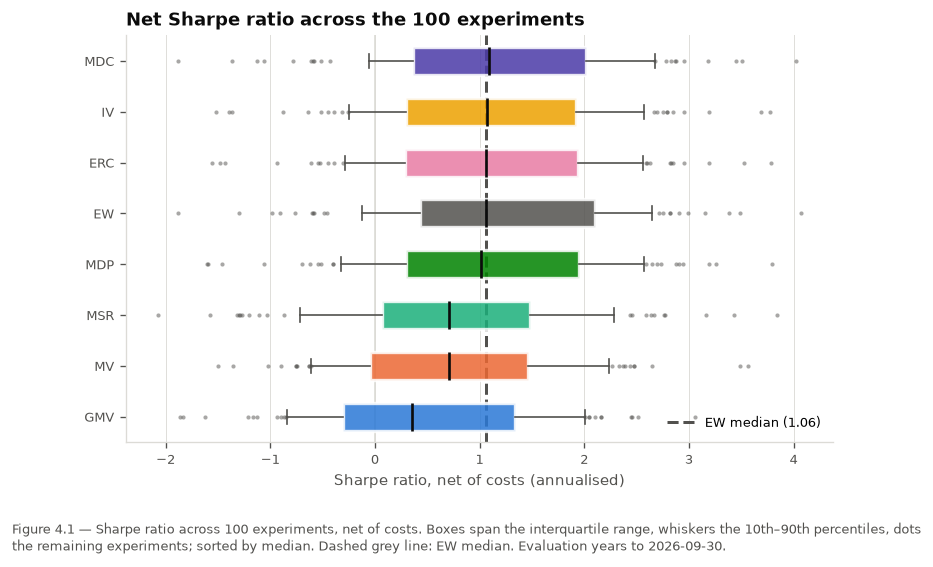

In [7]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))
viz.sharpe_boxplot(net_sharpe, ax=ax)
ax.set_title("Net Sharpe ratio across the 100 experiments")
viz.caption(ax, "Figure 4.1 — Sharpe ratio across 100 experiments, net of costs. Boxes span the interquartile "
                "range, whiskers the 10th–90th percentiles, dots the remaining experiments; sorted by median. "
                f"Dashed grey line: EW median. Evaluation years to {experiments['end'].max().date()}.")
plt.show()

---

## E6 — Figure 4.2, win rate vs equally weighted

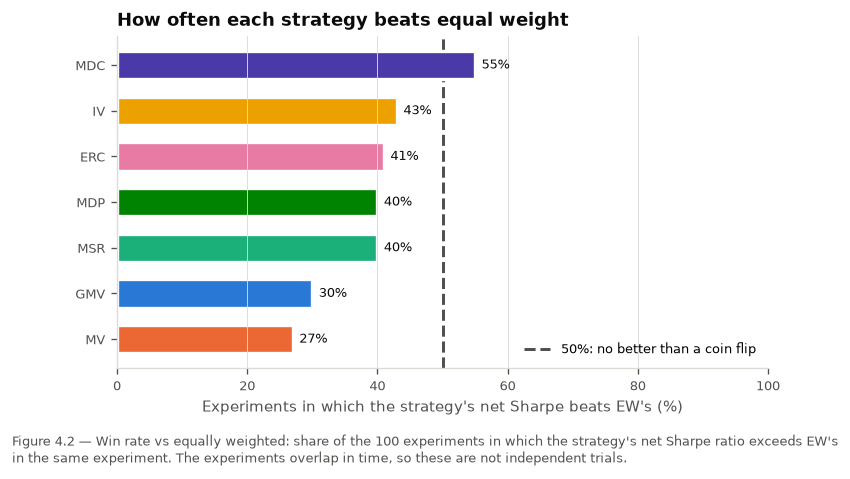

In [8]:
win = pf.win_rate(results)
fig, ax = plt.subplots(figsize=(7.0, 3.6))
viz.win_rate_bars(win, ax=ax)
ax.set_title("How often each strategy beats equal weight")
viz.caption(ax, "Figure 4.2 — Win rate vs equally weighted: share of the 100 experiments in which the strategy's "
                "net Sharpe ratio exceeds EW's in the same experiment. The experiments overlap in time, so "
                "these are not independent trials.")
plt.show()

---

## E7 — Table 4.4, cost impact

*Difference* is the median of the per-experiment differences between net and gross Sharpe, not the
difference of the two medians. *Cost drag* is the median gap between gross and net annual return,
in basis points. It includes the opening trade, which costs every strategy something.

In [9]:
table_4_4 = pf.cost_impact_table(results)
print("Table 4.4 - Cost impact. 100 experiments, medians. Costs per definitions §6 (one-way bp on |Δw|).")
display(fmt.style(table_4_4, {"Gross Sharpe": lambda v: fmt.number(v, 2), "Net Sharpe": lambda v: fmt.number(v, 2),
                              "Difference": lambda v: fmt.number(v, 2), "Cost drag bp/yr": lambda v: fmt.number(v, 1),
                              "Turnover %/yr": PCT(1)}))
print(f"Correlation of cost drag with turnover across strategies: "
      f"{table_4_4['Cost drag bp/yr'].corr(table_4_4['Turnover %/yr']):.2f}")

Table 4.4 - Cost impact. 100 experiments, medians. Costs per definitions §6 (one-way bp on |Δw|).


,Gross Sharpe,Net Sharpe,Difference,Cost drag bp/yr,Turnover %/yr
strategy,,,,,
EW,1.06,1.06,-0.01,18.8,31.8
GMV,0.36,0.35,-0.01,3.6,20.6
MV,0.71,0.71,-0.01,47.3,201.6
MSR,0.72,0.71,-0.01,35.4,177.9
IV,1.08,1.07,-0.01,8.8,27.8
ERC,1.07,1.06,-0.01,8.6,28.2
MDP,1.02,1.01,-0.01,8.7,35.6
MDC,1.10,1.09,-0.01,20.7,43.2


Correlation of cost drag with turnover across strategies: 0.94


**Costs do not change the picture at baseline rates.** Every strategy loses about 0.01 of Sharpe. The
strategies that pay for their own trading are **MV and MSR**: they turn over roughly six times as much
as the risk-based group and lose several times as many basis points a year. Even so, at these rates
the costs are small next to the gap in gross performance. Workstream F's 2× run (Table 5.1) tests
whether a harsher assumption reorders the ranking.

---

## E8 — Figure 4.3, growth of $1 in one experiment

**Which experiment, and why.** The figure needs one experiment, and choosing it by eye would cherry-pick.
The rule, fixed before drawing: take the experiment at the recommended strategy's **median net Sharpe
ratio**, the 50th of the 100 when sorted (the lower median, so that the choice is a single, actual
experiment). That is the recommended strategy's most typical year.

Representative experiment for ERC: #50, assets GC=F, GOVT, TSM, RNMBY, evaluation 2015-12-08 to 2016-12-06.
ERC net Sharpe here 1.05; median across experiments 1.06 (between the 50th and 51st).


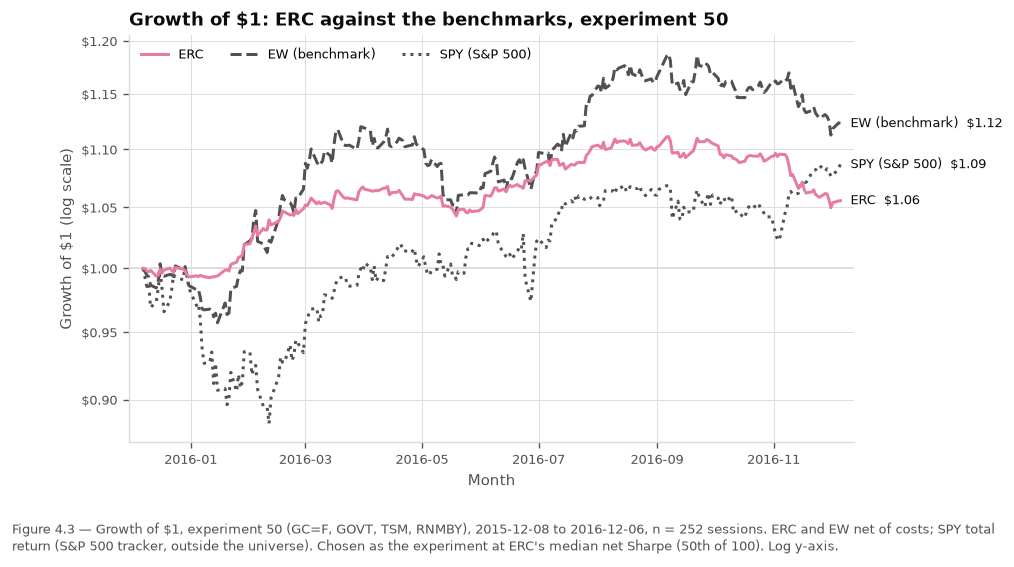

In [10]:
rep = pf.representative_experiment(results, RECOMMENDED)
e = experiments.loc[rep]
run = grid.runs[(rep, RECOMMENDED)]
ew_run = grid.runs[(rep, "EW")]
spy = panel.prices[cfg.PERFORMANCE_BENCHMARK].loc[e["estimation_end"]: e["end"]]
spy = spy / spy.iloc[0]

print(f"Representative experiment for {RECOMMENDED}: #{rep}, assets {', '.join(e['assets'])}, "
      f"evaluation {e['evaluation_start'].date()} to {e['end'].date()}.")
print(f"{RECOMMENDED} net Sharpe here {results.loc[(rep, RECOMMENDED), ('net', 'sharpe')]:.2f}; "
      f"median across experiments {net_sharpe[RECOMMENDED].median():.2f} (between the 50th and 51st).")

fig, ax = plt.subplots(figsize=(7.8, 4.4))
viz.wealth_paths(
    {RECOMMENDED: run.wealth()},
    {"EW (benchmark)": (ew_run.wealth(), cfg.BENCHMARK_STYLE),
     "SPY (S&P 500)": (spy, {**cfg.BENCHMARK_STYLE, "linestyle": ":"})},
    ax=ax,
)
ax.set_title(f"Growth of $1: {RECOMMENDED} against the benchmarks, experiment {rep}")
viz.caption(ax, f"Figure 4.3 — Growth of $1, experiment {rep} ({', '.join(e['assets'])}), "
                f"{e['evaluation_start'].date()} to {e['end'].date()}, n = {len(run.net)} sessions. "
                f"{RECOMMENDED} and EW net of costs; SPY total return (S&P 500 tracker, outside the universe). "
                f"Chosen as the experiment at {RECOMMENDED}'s median net Sharpe (50th of 100). Log y-axis.")
plt.show()

**Appendix — Figure A4.1, all eight strategies in the same experiment.** Small multiples, each against
EW, so that no panel carries more than two lines. EW is drawn on top. In the MDC panel the two lines
nearly coincide: MDC ignores volatility, and with these weakly and evenly correlated assets, minimising
correlation lands close to equal weight. The gap is printed below the figure.

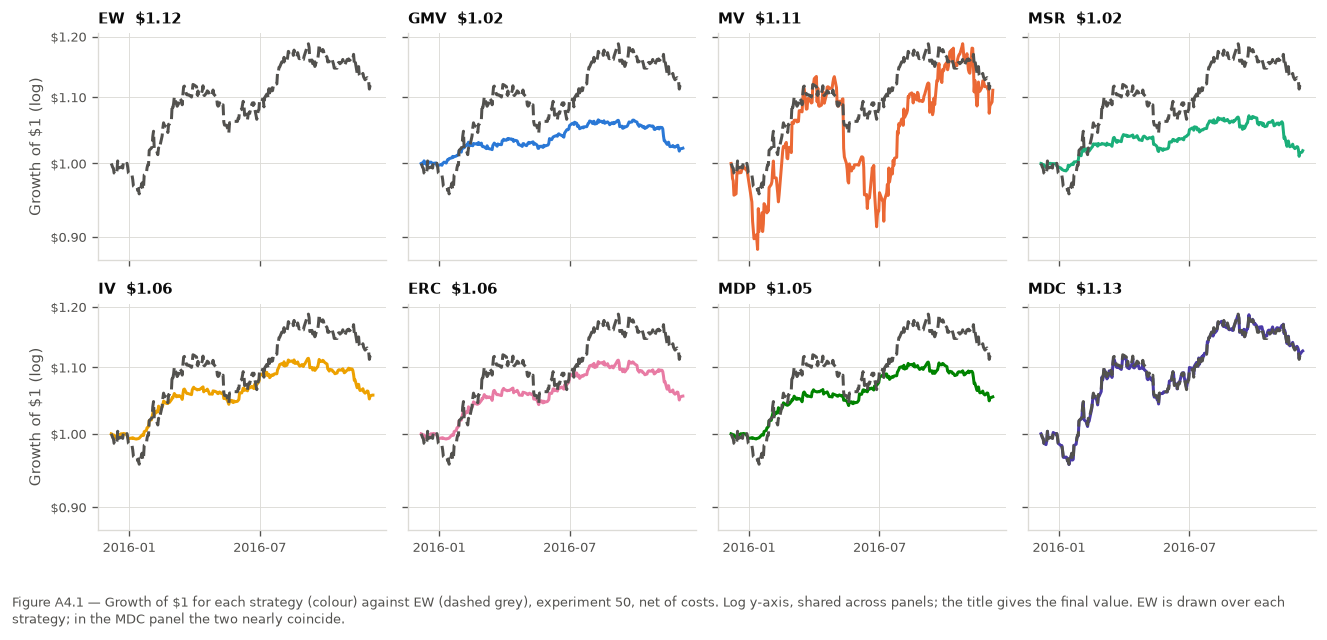

MDC vs EW in experiment 50: largest wealth gap 0.62%, largest weight gap 4.4 pp.


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(11, 4.8), sharex=True, sharey=True)
ew_wealth = ew_run.wealth()
for ax, s in zip(axes.flat, cfg.STRATEGY_ORDER):
    if s != "EW":
        w = grid.runs[(rep, s)].wealth()
        ax.plot(w.index, w, color=viz.strategy_color(s), label=s, zorder=2)
    # EW on top, so its dashes stay visible where a strategy tracks it closely (MDC).
    ax.plot(ew_wealth.index, ew_wealth, **cfg.BENCHMARK_STYLE, label="EW", zorder=3)
    ax.set_title(f"{s}  ${grid.runs[(rep, s)].wealth().iloc[-1]:.2f}", fontsize=9)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.2f}"))
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))
lo, hi = axes[0, 0].get_ylim()
axes[0, 0].yaxis.set_major_locator(plt.FixedLocator(np.arange(np.ceil(lo * 10) / 10, hi, 0.1)))
for ax in axes[:, 0]:
    ax.set_ylabel("Growth of $1 (log)")
fig.tight_layout()
viz.caption(axes[1, 0], f"Figure A4.1 — Growth of $1 for each strategy (colour) against EW (dashed grey), "
                        f"experiment {rep}, net of costs. Log y-axis, shared across panels; the title gives the "
                        "final value. EW is drawn over each strategy; in the MDC panel the two nearly coincide.")
plt.show()

mdc = grid.runs[(rep, "MDC")]
print(f"MDC vs EW in experiment {rep}: largest wealth gap "
      f"{(mdc.wealth() / ew_wealth - 1).abs().max() * 100:.2f}%, largest weight gap "
      f"{(mdc.weights - ew_run.weights).abs().max().max() * 100:.1f} pp.")

---

## E9 — Figure 4.4, weights over time

The recommended strategy's daily weights in the same experiment. Between the dotted rebalance lines,
the weights drift with returns, and they reset at each quarterly trade.

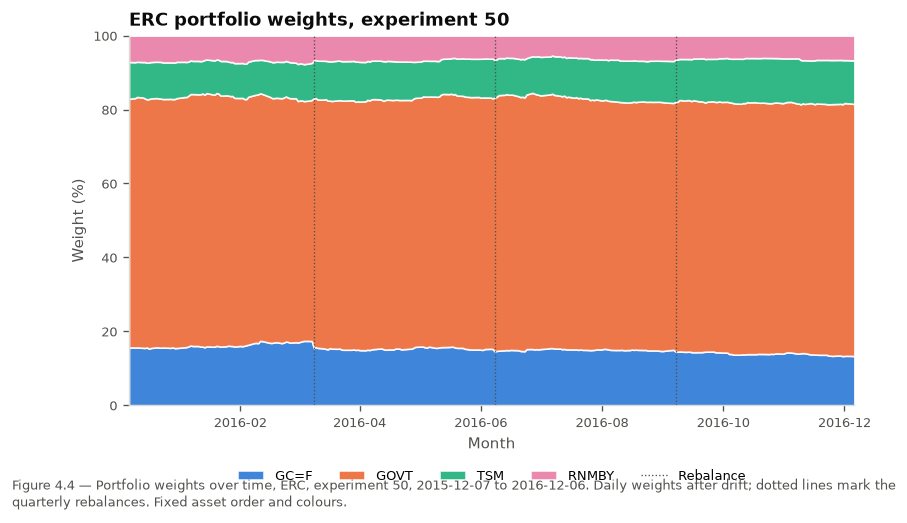

Mean weight %: {'GC=F': 15.1, 'GOVT': 67.7, 'TSM': 10.6, 'RNMBY': 6.6}


In [12]:
fig, ax = plt.subplots(figsize=(7.8, 4.0))
viz.weights_area(run.weights, list(run.trades["execution"].iloc[1:]), ax=ax)
ax.set_title(f"{RECOMMENDED} portfolio weights, experiment {rep}")
viz.caption(ax, f"Figure 4.4 — Portfolio weights over time, {RECOMMENDED}, experiment {rep}, "
                f"{run.weights.index[0].date()} to {run.weights.index[-1].date()}. Daily weights after drift; "
                "dotted lines mark the quarterly rebalances. Fixed asset order and colours.")
plt.show()

mean_w = run.weights.mean().reindex([a for a in cfg.ASSET_ORDER if a in run.weights.columns])
print("Mean weight %:", (mean_w * 100).round(1).to_dict())

The weights show ERC's best-known trait: **the lowest-volatility asset takes the largest weight**,
because it needs the most capital to contribute its equal share of risk. Its risk is balanced, but its
capital is concentrated. That is the shortcoming listed in Table 3.2, and workstream F's concentration
table (Table 5.3) measures it across all 100 experiments.

---

## Appendix — Table A4.1, gross performance

Table 4.2 before costs, for comparison.

In [13]:
table_a4_1 = pf.headline_table(results, "gross")
print("Table A4.1 - Gross performance by strategy. As Table 4.2, before transaction costs.")
display(fmt.style(table_a4_1, headline_rules))

Table A4.1 - Gross performance by strategy. As Table 4.2, before transaction costs.


metric,Ann. return %,Ann. vol %,Sharpe,Max DD %,Sterling,Turnover %/yr,Beats EW (Sharpe) %
strategy,,,,,,,
EW,22.60,20.40,1.06,-14.74,0.90,31.8,—
GMV,3.76,5.98,0.36,-5.29,0.28,20.6,30
MV,19.97,39.85,0.71,-29.84,0.65,201.6,28
MSR,11.94,25.55,0.72,-17.36,0.47,177.9,40
IV,11.05,9.15,1.08,-7.35,0.65,27.8,43
ERC,11.07,8.89,1.07,-7.35,0.64,28.2,41
MDP,10.40,8.48,1.02,-7.47,0.61,35.6,40
MDC,23.27,20.70,1.10,-15.34,0.93,43.2,55


---

## E10 — Table A.1, optimisation failures

From the C6 log. The table is shown even when it is short. Every listed rebalance kept its run, which
held its drifted weights.

In [14]:
failures = bt.failure_log(list(grid.runs.values()))
n_rebalances = len(grid.runs) * len(bt.Schedule().execution_positions())
print(f"Table A.1 - Optimisation failures. {len(failures)} of {n_rebalances:,} rebalances "
      f"({len(grid.runs)} runs x 4); no run dropped.")
if failures.empty:
    print("No optimisation failed.")
else:
    display(failures.assign(date=failures["date"].dt.date)
            .rename(columns={"experiment": "Experiment", "date": "Formation date", "strategy": "Strategy",
                             "error": "Error", "fallback": "Fallback used"}))

Table A.1 - Optimisation failures. 7 of 3,200 rebalances (800 runs x 4); no run dropped.


,Experiment,Formation date,Strategy,Error,Fallback used
0,1,2022-09-30,MSR,InfeasibleError: no asset has expected return above the risk-free rate (1.00%/yr); tangency portfolio undefined,Held drifted weights (no trade)
1,1,2022-12-30,MSR,InfeasibleError: no asset has expected return above the risk-free rate (1.99%/yr); tangency portfolio undefined,Held drifted weights (no trade)
2,16,2019-01-07,MSR,InfeasibleError: no asset has expected return above the risk-free rate (1.93%/yr); tangency portfolio undefined,Held drifted weights (no trade)
3,49,2022-09-23,MSR,InfeasibleError: no asset has expected return above the risk-free rate (0.94%/yr); tangency portfolio undefined,Held drifted weights (no trade)
4,49,2022-12-22,MSR,InfeasibleError: no asset has expected return above the risk-free rate (1.90%/yr); tangency portfolio undefined,Held drifted weights (no trade)
5,88,2022-05-13,MSR,InfeasibleError: no asset has expected return above the risk-free rate (0.19%/yr); tangency portfolio undefined,Held drifted weights (no trade)
6,92,2018-11-19,MSR,InfeasibleError: no asset has expected return above the risk-free rate (1.81%/yr); tangency portfolio undefined,Held drifted weights (no trade)


---

## Done-when checks

In [15]:
checks = []
checks.append(("Table 4.2 is net of costs and covers the eight strategies in fixed order",
               list(table_4_2.index) == cfg.STRATEGY_ORDER and table_4_2.notna().drop(columns="Beats EW (Sharpe) %").all().all()))

again = pf.headline_table(pf.results_frame(
    pf.run_grid(prices, bt.sample_experiments(prices), st.STRATEGIES, panel.risk_free), panel.risk_free), "net")
checks.append(("Every number in Table 4.2 reproduces under the fixed seed", again.equals(table_4_2)))

checks.append(("Net and gross differ, and net is never above gross",
               (table_4_2["Ann. return %"] <= table_a4_1["Ann. return %"] + 1e-12).all()))
checks.append(("Win rate reported for every strategy but EW", win.drop("EW").notna().all()))
checks.append(("Table A.1 built from the failure log (no run dropped)",
               len(results) == cfg.N_EXPERIMENTS * len(cfg.STRATEGY_ORDER)))

for label, ok in checks:
    print(f"[{'PASS' if ok else 'FAIL'}] {label}")
assert all(ok for _, ok in checks), "workstream E exit criteria not met"

[PASS] Table 4.2 is net of costs and covers the eight strategies in fixed order
[PASS] Every number in Table 4.2 reproduces under the fixed seed
[PASS] Net and gross differ, and net is never above gross
[PASS] Win rate reported for every strategy but EW
[PASS] Table A.1 built from the failure log (no run dropped)


---

## Handoff

| Output | Report |
| --- | --- |
| Table 4.1 | Section 4, *Methods and assumptions* |
| Tables 4.2–4.4, Figures 4.1–4.4 | Section 5, *Results* |
| Tables A4.1, A.1; Figure A4.1 | Appendix |
| `RECOMMENDED = "ERC"` | Sections 1 and 7. Stated objective: capital preservation / moderate risk. Same median Sharpe as EW at under half the volatility and drawdown |

Workstream F (notebook 07) reuses `results`: `net_2x` for Table 5.1, `experiments` for the period and
subset splits, and `grid.runs` for concentration.